# Model Training

### Setup MLFlow

In [ ]:
# # SETUP BLOCK (Run once per project lifetime)
# import mlflow
# import os

# # 1. Define Absolute Paths
# project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# db_uri = f"sqlite:///{os.path.join(project_root, 'mlflow.db')}"
# artifact_uri = "file:///" + os.path.join(project_root, "mlruns").replace("\\", "/")

# # 2. Connect
# mlflow.set_tracking_uri(db_uri)

# # 3. Create (Safe Check)
# if not mlflow.get_experiment_by_name("WaterQuality"):
#     mlflow.create_experiment("WaterQuality", artifact_location=artifact_uri)

In [1]:
import mlflow
import sys
import os

sys.path.append(os.path.abspath(".."))

# --- ENVIRONMENT TOGGLE ---
ENV = 'local' # Change to 'snowflake' when you deploy to the cloud

if ENV == 'local':
    from src import config_local as config
else:
    from src import config_snowflake as config

# Set tracking URI dynamically
mlflow.set_tracking_uri(config.MLFLOW_URI)
mlflow.set_experiment("WaterQuality")

2026/03/12 10:10:01 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/03/12 10:10:01 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/03/12 10:10:01 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/03/12 10:10:01 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/03/12 10:10:01 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/03/12 10:10:01 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/03/12 10:10:02 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/12 10:10:02 INFO alembic.runtime.migration: Will assume non-transactional DDL.


<Experiment: artifact_location='file:///d:/projects/water-quality-prediction/notebooks/mlruns/1', creation_time=1773038149702, experiment_id='1', last_update_time=1773038149702, lifecycle_stage='active', name='WaterQuality', tags={'mlflow.experimentKind': 'custom_model_development'}>

### Import Libraries

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import shap
import time

from tqdm.auto import tqdm

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.inspection import permutation_importance
from sklearn.base import clone
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict

# Regression Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.linear_model import Ridge, Lasso
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import ExtraTreesRegressor, StackingRegressor

warnings.filterwarnings("ignore")

### Load Data

In [3]:
# Dynamically load data based on environment toggle
df = config.load_data()

In [4]:
def engineer_features(data):
    df_eng = data.copy()
    
    # Human & Hydrological Density
    # Population Density per Upstream Area: Concentration of human impact
    df_eng['pop_density_upstream'] = df_eng['worldpop_mean_1km'] / (df_eng['basin_upstream_area_km2'] + 1e-5)
    
    # Specific Discharge (Water Yield): Flow relative to the basin size
    df_eng['specific_discharge'] = df_eng['river_avg_discharge_cms'] / (df_eng['basin_upstream_area_km2'] + 1e-5)
    
    return df_eng

# Apply the engineering immediately after loading
df = engineer_features(df)

In [5]:
# # 1. Assign LORO Regions (Required for CV Folds)
# def assign_region(row):
#     if row['Latitude'] >= -30.0:
#         return 'Northern_Bulk'
#     elif row['Longitude'] < 22.5:
#         return 'Western_Cape'
#     else:
#         return 'Eastern_Cape'

# df['Region'] = df.apply(assign_region, axis=1)

# # 2. Drop Spatial Anchors (Prevent Spatial Leakage)
# SPATIAL_COLS = ['Latitude', 'Longitude', 'Sample Date']
# df = df.drop(columns=SPATIAL_COLS)

TARGET_COLS = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']
META_COLS = ['Region']

# 3. Unsupervised Pre-Filter
initial_features = [col for col in df.columns if col not in TARGET_COLS + META_COLS]
print(f"Initial features from DE: {len(initial_features)}")

# Variance Check
var_filter = VarianceThreshold(threshold=0.0)
var_filter.fit(df[initial_features].fillna(0))
non_constant_features = [f for f, s in zip(initial_features, var_filter.get_support()) if s]
print(f"Dropped {len(initial_features) - len(non_constant_features)} zero-variance features.")

# Collinearity Check
CORR_THRESHOLD = 0.90 
corr_matrix = df[non_constant_features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper.columns if any(upper[column] > CORR_THRESHOLD)]
print(f"Dropped {len(to_drop_corr)} highly correlated features.")

UNIVERSAL_FEATURES = [f for f in non_constant_features if f not in to_drop_corr]
print(f"Final lean feature count ready for baseline training: {len(UNIVERSAL_FEATURES)}")

Initial features from DE: 30
Dropped 7 zero-variance features.
Dropped 2 highly correlated features.
Final lean feature count ready for baseline training: 21


### Define Model Hyperparameters & Preprocessor

In [6]:
data_params = {
    "validation_strategy": "Leave-One-Region-Out (LORO) Spatial CV",
    "folds": "3 (Northern_Bulk, Western_Cape, Eastern_Cape)",
    "pipeline_architecture": "ColumnTransformer (Fit strictly INSIDE CV loops)",
    "imputation_strategy": "Median via Train Folds Only",
    "target_handling": "Raw Values (Disabled log1p to match benchmark)",
    "variance_strategy": "VarianceThreshold(threshold=0.0) to drop zero-variance features",
    "collinearity_strategy": "Absolute Pearson correlation filter with threshold=0.90; drop one feature from each highly correlated pair"
}

def get_preprocessor():
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median', add_indicator=False)),
        ('scaler', StandardScaler()),
    ])
    return ColumnTransformer(
        transformers=[('num', numeric_transformer, UNIVERSAL_FEATURES)],
        remainder='drop'
    )

In [7]:
# --- Log Wrapper ---
def log_wrap(model):
    return TransformedTargetRegressor(
        regressor=model, 
        func=np.log1p, 
        inverse_func=np.expm1
    )

# --- Base Models ---
ridge_base = Ridge(alpha=10.0)
lasso_base = Lasso(alpha=0.001)  # The Alpha that saved the pipeline

etr_shallow = ExtraTreesRegressor(
    n_estimators=200, 
    max_depth=10, 
    random_state=42, 
    n_jobs=-1
)

xgb_conservative = XGBRegressor(
    n_estimators=300, 
    learning_rate=0.03, 
    max_depth=4,         
    subsample=0.7, 
    colsample_bytree=0.6,
    reg_alpha=1.0, 
    reg_lambda=5.0,      
    random_state=42, 
    n_jobs=-1
)

base_estimators = [
    ('ridge', ridge_base),
    ('lasso', lasso_base),
    ('etr_shallow', etr_shallow),
    ('xgb_conservative', xgb_conservative)
]

# --- Meta-Learner & Stack ---
meta_learner = KernelRidge(alpha=0.001, kernel='poly', degree=2, coef0=0.5)

stacked_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=meta_learner,
    passthrough=False,  # Strict leakage block
    cv=3 
)

# --- Final Dictionary ---
models = {
    "Ridge_Log": log_wrap(ridge_base),
    "Lasso_Log": log_wrap(lasso_base),
    "XGBoost_Log": log_wrap(xgb_conservative),
    "StackedModel_Log": log_wrap(stacked_model)
}

In [ ]:
# # 1. Define the Base Models (The "Council")
# # We use ExtraTrees with slight variations to ensure they learn differently
# base_estimators = [
#     ('etr_shallow', ExtraTreesRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
#     ('etr_deep', ExtraTreesRegressor(n_estimators=100, max_depth=25, min_samples_split=5, random_state=42, n_jobs=-1))
# ]

# # 2. Define the Meta-Learner (The "Smoother")
# # The winner used Ridge with a polynomial kernel. We start with standard Ridge as a safe baseline.
# meta_learner = KernelRidge(alpha=0.00001, kernel='poly', degree=2, coef0=0.25)

# # 3. Build the Stack
# stacked_model = StackingRegressor(
#     estimators=base_estimators,
#     final_estimator=meta_learner,
#     passthrough=False # Set to True if you want Ridge to also see the raw features
# )

# # 4. Add to your pipeline
# models = {
#     "Ridge": Ridge(alpha=1.0),
#     "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
#     "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1),
#     "StackedModel": stacked_model # <--- Ready for the new data!
# }

### Model Training & Evaluation

p.s. We may need to split `numeric_transformer` into two: one that imputes medians for weather/satellite data, and one that imputes 0 for GIS buffers.

In [10]:
results = []

# Explicitly define the LORO cross-validation strategy
logo = LeaveOneGroupOut()
groups = df['Region']

# Calculate total iterations for the outer progress bar (3 targets * 4 models = 12 runs)
total_runs = len(TARGET_COLS) * len(models)

# 1. Outer Progress Bar
with tqdm(total=total_runs, desc="Overall Progress") as pbar:
    for target in TARGET_COLS:
        
        # Prepare full target and features arrays to feed into the parallel engine
        X_all_raw = df[UNIVERSAL_FEATURES]
        y_all = df[target]
        
        for model_name, base_model in models.items():
            run_name = f"{model_name}_{target.replace(' ', '')}_LORO"
            
            with mlflow.start_run(run_name=run_name):
                tqdm.write(f"\n--- Cross-Validating {run_name} ---")
                cv_start_time = time.time()
                
                # ==========================================
                # 1. The Parallel LORO Cross-Validation
                # ==========================================
                # CRITICAL: Bind the preprocessor to the model to prevent spatial leakage
                fold_pipeline = Pipeline([
                    ('preprocessor', get_preprocessor()),
                    ('model', clone(base_model))
                ])
                
                # 🚀 The Turbocharger: Runs all 9 folds simultaneously across the XL Warehouse
                oof_y_pred = cross_val_predict(
                    estimator=fold_pipeline,
                    X=X_all_raw,
                    y=y_all,
                    groups=groups,
                    cv=logo,
                    n_jobs=-1,  # Tells Python to use every available Snowflake CPU core
                    verbose=0   # Kept at 0 to avoid cluttering your notebook terminal
                )
                
                # cross_val_predict returns predictions in the exact original order
                oof_y_true = y_all.values
                cv_time = time.time() - cv_start_time
                
                # ==========================================
                # 2. Honest OOF Scoring & Logging
                # ==========================================
                metrics = {
                    "rmse": np.sqrt(mean_squared_error(oof_y_true, oof_y_pred)),
                    "mae": mean_absolute_error(oof_y_true, oof_y_pred),
                    "r2": r2_score(oof_y_true, oof_y_pred),
                    "cv_time_sec": cv_time
                }
                
                mlflow.log_param("target", target)
                mlflow.log_param("model", model_name)
                mlflow.log_metrics(metrics)
                
                # Actual vs Predicted Plot (Using OOF Predictions)
                fig, ax = plt.subplots(figsize=(6, 6))
                ax.scatter(oof_y_true, oof_y_pred, alpha=0.4, color='teal')
                min_val = min(oof_y_true.min(), oof_y_pred.min())
                max_val = max(oof_y_true.max(), oof_y_pred.max())
                ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
                ax.set_xlabel('Actual Values (All Folds)')
                ax.set_ylabel('Predicted Values (OOF)')
                ax.set_title(f'True Generalization - {run_name}')
                mlflow.log_figure(fig, f'{run_name}_actual_vs_predicted_oof.png')
                plt.close(fig)

                # ==========================================
                # 3. Retrain on 100% of Data for Submission
                # ==========================================
                tqdm.write("  Retraining final model on 100% of data...")
                
                # We do this step manually (outside a pipeline) to easily save the separate artifacts
                final_preprocessor = get_preprocessor()
                X_all_processed = final_preprocessor.fit_transform(X_all_raw)
                
                final_model = clone(base_model)
                final_model.fit(X_all_processed, y_all)
                
                # Save the final Preprocessor and Model artifacts locally
                config.save_artifacts(final_preprocessor, final_model, run_name)
                
                # Log final model to MLflow
                mlflow.sklearn.log_model(final_model, name="model")
                
                results.append({
                    "target": target,
                    "model": model_name,
                    "rmse": metrics["rmse"],
                    "mae": metrics["mae"],
                    "r2": metrics["r2"]
                })
            
            # Update the outer progress bar after completing a full target/model run
            pbar.update(1)

print("\n=== All 12 parallel LORO runs complete! Models trained on 100% data and logged to MLflow. ===")

Overall Progress:   0%|          | 0/12 [00:00<?, ?it/s]


--- Cross-Validating Ridge_Log_TotalAlkalinity_LORO ---
  Retraining final model on 100% of data...
✅ Artifacts saved locally.

--- Cross-Validating Lasso_Log_TotalAlkalinity_LORO ---
  Retraining final model on 100% of data...
✅ Artifacts saved locally.

--- Cross-Validating XGBoost_Log_TotalAlkalinity_LORO ---
  Retraining final model on 100% of data...
✅ Artifacts saved locally.

--- Cross-Validating StackedModel_Log_TotalAlkalinity_LORO ---
  Retraining final model on 100% of data...
✅ Artifacts saved locally.

--- Cross-Validating Ridge_Log_ElectricalConductance_LORO ---
  Retraining final model on 100% of data...
✅ Artifacts saved locally.

--- Cross-Validating Lasso_Log_ElectricalConductance_LORO ---
  Retraining final model on 100% of data...
✅ Artifacts saved locally.

--- Cross-Validating XGBoost_Log_ElectricalConductance_LORO ---
  Retraining final model on 100% of data...
✅ Artifacts saved locally.

--- Cross-Validating StackedModel_Log_ElectricalConductance_LORO ---
  Ret

### Model Comparison

In [12]:
results_df = pd.DataFrame(results)

model_order = ["Ridge_Log", "Lasso_Log", "XGBoost_Log", "StackedModel_Log"]
available_models = [m for m in model_order if m in results_df["model"].unique()]

# Pivot for a clean comparison view
for metric in ["rmse", "mae", "r2"]:
    print(f"\n{'='*50}")
    print(f"  {metric.upper()} by Target × Model")
    print(f"{'='*50}")
    
    pivot = results_df.pivot(index="target", columns="model", values=metric)
    pivot = pivot[available_models]

    if metric in ["rmse", "mae"]:
        display(pivot.style.highlight_min(axis=1, color="green").format("{:.4f}"))
    else:
        display(pivot.style.highlight_max(axis=1, color="green").format("{:.4f}"))


  RMSE by Target × Model


model,Ridge_Log,Lasso_Log,XGBoost_Log,StackedModel_Log
target,,,,
Dissolved Reactive Phosphorus,56.4713,56.3456,56.3015,55.9738
Electrical Conductance,373.8023,376.0323,332.5828,342.3728
Total Alkalinity,85.7095,99.1288,67.8033,71.4905



  MAE by Target × Model


model,Ridge_Log,Lasso_Log,XGBoost_Log,StackedModel_Log
target,,,,
Dissolved Reactive Phosphorus,32.4486,32.4498,31.7117,31.3869
Electrical Conductance,286.7638,288.3597,247.2796,254.5682
Total Alkalinity,67.5401,73.2091,52.6327,54.3465



  R2 by Target × Model


model,Ridge_Log,Lasso_Log,XGBoost_Log,StackedModel_Log
target,,,,
Dissolved Reactive Phosphorus,-0.2272,-0.2217,-0.2198,-0.2056
Electrical Conductance,-0.1952,-0.2095,0.0539,-0.0027
Total Alkalinity,-0.3169,-0.7615,0.1759,0.0838


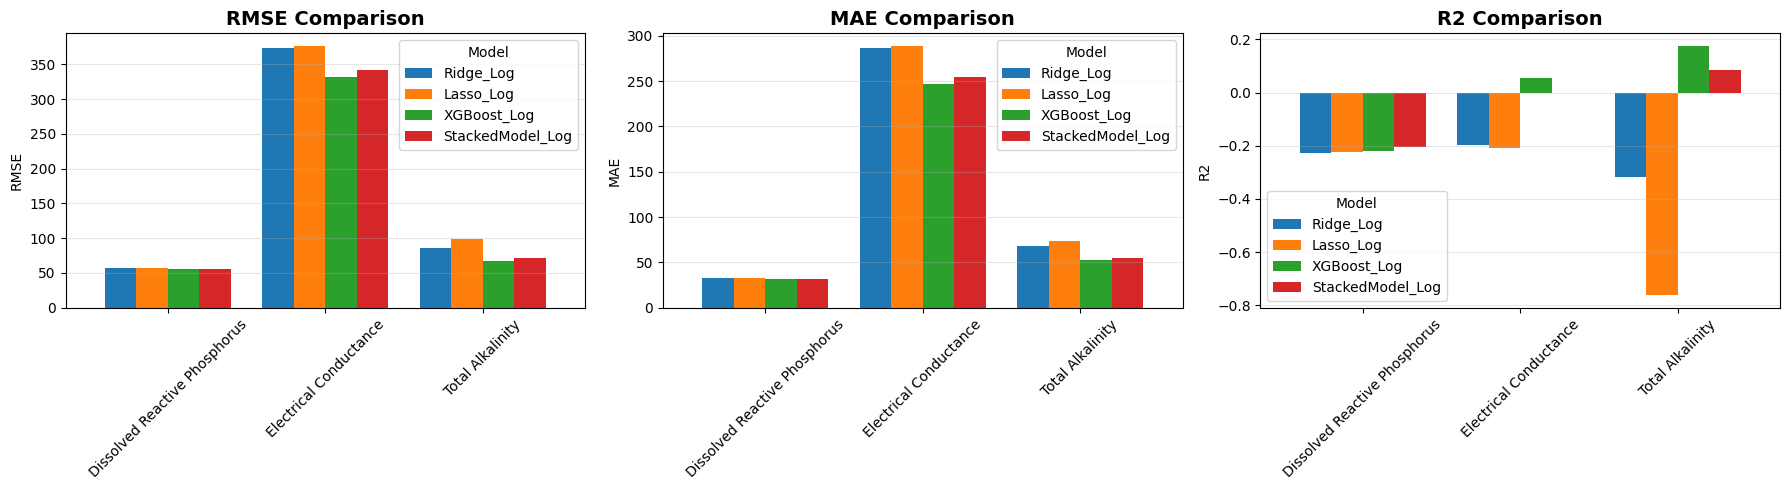


Saved to ../reports/model_comparison.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_order = ["Ridge_Log", "Lasso_Log", "XGBoost_Log", "StackedModel_Log"]
available_models = [m for m in model_order if m in results_df["model"].unique()]

for ax, metric in zip(axes, ["rmse", "mae", "r2"]):
    pivot = results_df.pivot(index="target", columns="model", values=metric)
    pivot = pivot[available_models]
    pivot.plot(kind="bar", ax=ax, rot=45, width=0.8)

    ax.set_title(f"{metric.upper()} Comparison", fontsize=14, fontweight="bold")
    ax.set_ylabel(metric.upper())
    ax.set_xlabel("")
    ax.legend(title="Model", loc="best")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved to ../reports/model_comparison.png")